In [40]:
import pandas as pd

df = pd.read_csv("mobile_game_inapp_purchases.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()

# strip leading/trailing whitespace from ALL column names
df.columns = df.columns.str.strip()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [41]:
import numpy as np

# converting date
df["LastPurchaseDate"] = pd.to_datetime(df["LastPurchaseDate"])
df["PurchaseMonth"] = df["LastPurchaseDate"].dt.month
df["PurchaseDay"] = df["LastPurchaseDate"].dt.day
df["PurchaseWeekDay"] = df["LastPurchaseDate"].dt.weekday
# dropping original date column
df = df.drop(columns=["LastPurchaseDate"])
# dropping UserID as it's not useful for prediction later
df = df.drop(columns=["UserID"])

# handle missing spend (non-payers)
df['InAppPurchaseAmount'] = df['InAppPurchaseAmount'].fillna(0)

# create payer flag
df['payer_flag'] = np.where(df['InAppPurchaseAmount'] > 0, 1, 0)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            2964 non-null   float64
 1   Gender                         2964 non-null   object 
 2   Country                        2964 non-null   object 
 3   Device                         2964 non-null   object 
 4   GameGenre                      2964 non-null   object 
 5   SessionCount                   3024 non-null   int64  
 6   AverageSessionLength           3024 non-null   float64
 7   SpendingSegment                3024 non-null   object 
 8   InAppPurchaseAmount            3024 non-null   float64
 9   FirstPurchaseDaysAfterInstall  2888 non-null   float64
 10  PaymentMethod                  2888 non-null   object 
 11  PurchaseMonth                  2888 non-null   float64
 12  PurchaseDay                    2888 non-null   f

In [8]:
## monetization metrics
total_revenue = df['InAppPurchaseAmount'].sum()
total_revenue

296259.31000000006

In [9]:
# payer rate
payer_rate = df['payer_flag'].mean() * 100
payer_rate

95.46957671957672

In [11]:
# avg rate per user (all)
arpu = df['InAppPurchaseAmount'].mean()
arpu

97.96934854497357

In [12]:
# avg rate per user (paying users)
arppu = df[df['payer_flag'] == 1]['InAppPurchaseAmount'].mean()
arppu

102.61839625909246

In [13]:
## rev concentration : whale analysis
user_spend = df['InAppPurchaseAmount']

top_5_threshold = user_spend.quantile(0.95)

top_5_revenue_share = (
    user_spend[user_spend >= top_5_threshold].sum() /
    user_spend.sum()
)

top_5_revenue_share

0.7233389897519168

In [14]:
# comparing with existing SpendingSegment
df.groupby('SpendingSegment')['InAppPurchaseAmount'].agg(['count','mean','sum'])

,count,mean,sum
SpendingSegment,,,
Dolphin,412,233.71068,96288.80
Minnow,2544,9.58623,24387.37
Whale,68,2582.10500,175583.14


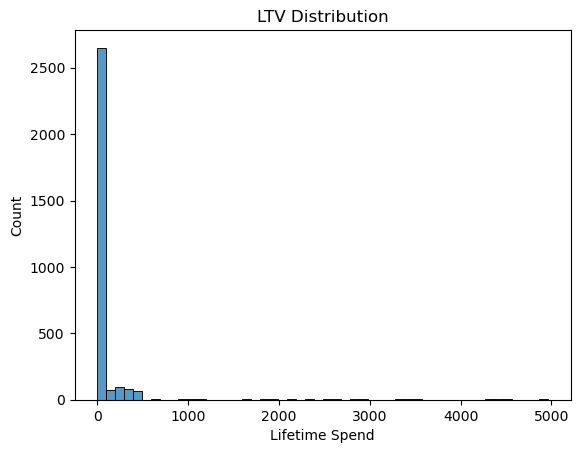

In [15]:
## LTV distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['InAppPurchaseAmount'], bins=50)
plt.title("LTV Distribution")
plt.xlabel("Lifetime Spend")
plt.show()

In [17]:
## what drives high spending?

# session behavior
df.groupby('SpendingSegment')[['SessionCount','AverageSessionLength']].mean()

,SessionCount,AverageSessionLength
SpendingSegment,,
Dolphin,10.123786,20.035704
Minnow,10.044025,20.137445
Whale,10.926471,17.931471


In [18]:
# first purchase timing
df.groupby('SpendingSegment')['FirstPurchaseDaysAfterInstall'].mean()

SpendingSegment
Dolphin    15.834184
Minnow     15.284012
Whale      16.444444
Name: FirstPurchaseDaysAfterInstall, dtype: float64

In [19]:
# if whales purchase earlier → early monetization strategy matters

In [20]:
# device differences
df.groupby('Device')['InAppPurchaseAmount'].mean()

Device
Android     90.748913
iOS        105.617961
Name: InAppPurchaseAmount, dtype: float64

In [21]:
# genre rev
df.groupby('GameGenre')['InAppPurchaseAmount'].mean().sort_values(ascending=False)

GameGenre
Racing           152.688796
Battle Royale    148.395714
Strategy         136.700101
MOBA             133.647459
Fighting         133.579669
MMORPG            93.153333
Adventure         92.426235
Role Playing      88.241244
Simulation        81.297763
Card              81.149257
Casual            75.518373
Sports            74.506452
Puzzle            69.407330
Sandbox           64.547717
Action RPG        60.667853
Name: InAppPurchaseAmount, dtype: float64

In [22]:
## creating revenue tier flags

df['ltv_percentile'] = pd.qcut(
    df['InAppPurchaseAmount'],
    q=4,
    labels=['Low','Mid-Low','Mid-High','High']
)

In [23]:
# comparing behavior
df.groupby('ltv_percentile')[['SessionCount','AverageSessionLength','FirstPurchaseDaysAfterInstall']].mean()

/tmp/ipykernel_126/1920498218.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ltv_percentile')[['SessionCount','AverageSessionLength','FirstPurchaseDaysAfterInstall']].mean()


,SessionCount,AverageSessionLength,FirstPurchaseDaysAfterInstall
ltv_percentile,,,
Low,10.252312,20.378230,15.637681
Mid-Low,9.860927,19.755815,15.217219
Mid-High,10.111111,20.013677,15.034392
High,10.074074,20.147368,15.691799


In [24]:
## correlation with spend

df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()

corr['InAppPurchaseAmount'].sort_values(ascending=False)

InAppPurchaseAmount                            1.000000
SpendingSegment_Whale                          0.847748
ltv_percentile_High                            0.349590
UserID_b5c61dc0-138d-4d49-ae4a-c4ca75787cb2    0.199152
UserID_9ce85d56-3f8f-431a-b0bf-eec096811b39    0.197824
                                                 ...   
Country_Australia                             -0.026072
AverageSessionLength                          -0.027899
ltv_percentile_Mid-High                       -0.108462
ltv_percentile_Mid-Low                        -0.116433
SpendingSegment_Minnow                        -0.457822
Name: InAppPurchaseAmount, Length: 3084, dtype: float64

In [48]:
# features & target
X = df.drop(columns=["InAppPurchaseAmount"])
y = df["InAppPurchaseAmount"].astype(float)

print("\nFinal Feature Count:", X.shape[1])


Final Feature Count: 14


In [51]:
# train/test split

# encode all object/category columns in a single shot
X_enc = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
)

In [52]:
# train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
# predictions
from sklearn.metrics import mean_squared_error, r2_score

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\nModel Performance:")
print("R^2 Score:", round(r2, 4))
print("RMSE:", round(rmse, 4))


Model Performance:
R^2 Score: 0.7863
RMSE: 249.1094


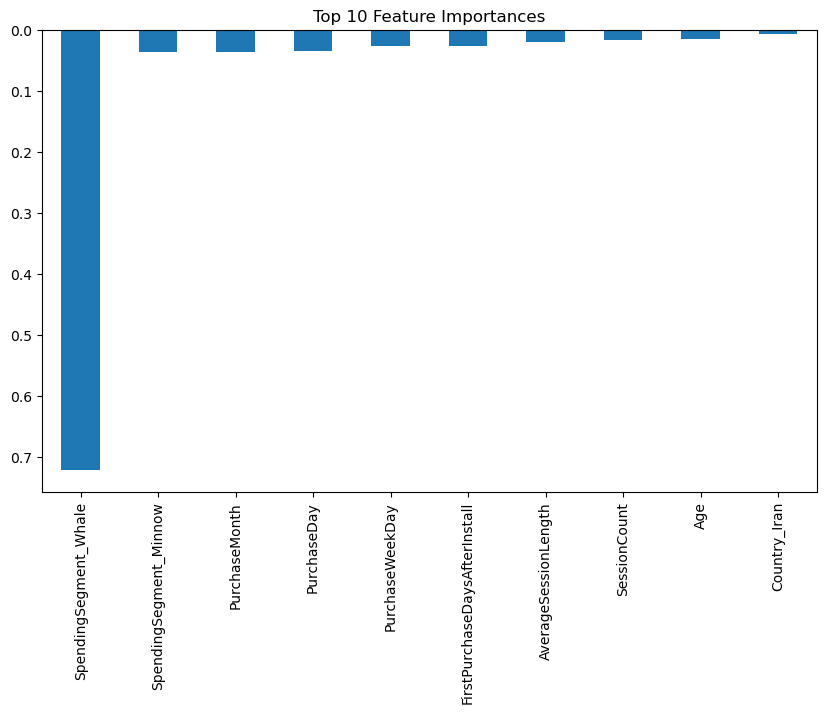

In [61]:
# feat imp
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)


plt.figure(figsize=(10,6))
top_features.plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [63]:
# pricing simulation

current_revenue = df['InAppPurchaseAmount'].sum()
dolphin_mask = df['SpendingSegment'] == "Dolphin"

simulated_revenue = current_revenue + (
    df.loc[dolphin_mask, 'InAppPurchaseAmount'].sum() * 0.05
        )
impact = simulated_revenue - current_revenue
impact

4814.440000000002

In [65]:
# ===============================
# EXECUTIVE METRICS CALCULATION
# ===============================

total_users = len(df)
payers = df[df["InAppPurchaseAmount"] > 0]

payer_rate = len(payers) / total_users * 100
arpu = df["InAppPurchaseAmount"].mean()
arppu = payers["InAppPurchaseAmount"].mean()

# top 5% Revenue Contribution
top_5_cutoff = np.percentile(df["InAppPurchaseAmount"], 95)
top_5 = df[df["InAppPurchaseAmount"] >= top_5_cutoff]

top_5_revenue_share = top_5["InAppPurchaseAmount"].sum() / df["InAppPurchaseAmount"].sum() * 100

# whale early purchase behavior
whales = top_5
avg_whale_first_purchase_days = whales["FirstPurchaseDaysAfterInstall"].mean()

# correlation: Session Frequency vs LTV
session_ltv_corr = df["SessionCount"].corr(df["InAppPurchaseAmount"])

# device monetization comparison
device_monetization = df.groupby("Device")["InAppPurchaseAmount"].mean()

print("Payer Rate:", round(payer_rate,2), "%")
print("ARPU: $", round(arpu,2))
print("ARPPU: $", round(arppu,2))
print("Top 5% Revenue Share:", round(top_5_revenue_share,2), "%")
print("Whales Avg First Purchase (Days):", round(avg_whale_first_purchase_days,2))
print("Session Count - LTV Correlation:", round(session_ltv_corr,3))
print("\nMonetization by Device:\n", device_monetization)

Payer Rate: 95.47 %
ARPU: $ 97.97
ARPPU: $ 102.62
Top 5% Revenue Share: 72.33 %
Whales Avg First Purchase (Days): 15.39
Session Count ↔ LTV Correlation: 0.035

Monetization by Device:
 Device
Android     90.748913
iOS        105.617961
Name: InAppPurchaseAmount, dtype: float64
